<a href="https://colab.research.google.com/github/s6604053620019-a11y/apptch/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading and Exploration

### Subtask:
Load the IMDB dataset and perform an initial inspection of its structure and quality.


**Reasoning**:
I will load the IMDB dataset, display the first few rows, and provide a summary of the data's structure and descriptive statistics as requested in the instructions.



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/IMDB-Movie-Data.csv')

# Display the first few rows
print('--- First 5 Rows ---')
display(df.head())

# Check info for data types and missing values
print('\n--- DataFrame Info ---')
df.info()

# Descriptive statistics for numerical features
print('\n--- Descriptive Statistics ---')
display(df.describe())

--- First 5 Rows ---


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB

--- Descriptive Statistics ---


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## Data Cleaning

### Subtask:
Handle missing values and prepare the dataset for analysis.


**Reasoning**:
I will perform data cleaning by handling missing values in 'Revenue (Millions)' and 'Metascore', verifying the cleaning results, and renaming columns for easier access as specified in the instructions.



In [ ]:
import pandas as pd

# 1. Fill missing values in 'Revenue (Millions)' with the median
revenue_median = df['Revenue (Millions)'].median()
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(revenue_median)

# 2. Fill missing values in 'Metascore' with the mean
metascore_mean = df['Metascore'].mean()
df['Metascore'] = df['Metascore'].fillna(metascore_mean)

# 3. Verify no remaining missing values
print('--- Missing Values Count After Imputation ---')
print(df.isnull().sum())

# 4. Rename columns to remove spaces and special characters
df.rename(columns={
    'Runtime (Minutes)': 'Runtime_Minutes',
    'Revenue (Millions)': 'Revenue_Millions'
}, inplace=True)

print('\n--- Updated Column Names ---')
print(df.columns.tolist())

# Display the first few rows of the cleaned dataframe
display(df.head())

--- Missing Values Count After Imputation ---
Rank                  0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime (Minutes)     0
Rating                0
Votes                 0
Revenue (Millions)    0
Metascore             0
dtype: int64

--- Updated Column Names ---
['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime_Minutes', 'Rating', 'Votes', 'Revenue_Millions', 'Metascore']


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Exploratory Data Analysis (EDA)

### Subtask:
Analyze relationships between movie features and visualize distributions to identify patterns.


**Reasoning**:
I will perform Exploratory Data Analysis by visualizing correlations, distributions of the target variable, and analyzing the impact of Genre on movie ratings as specified in the instructions.



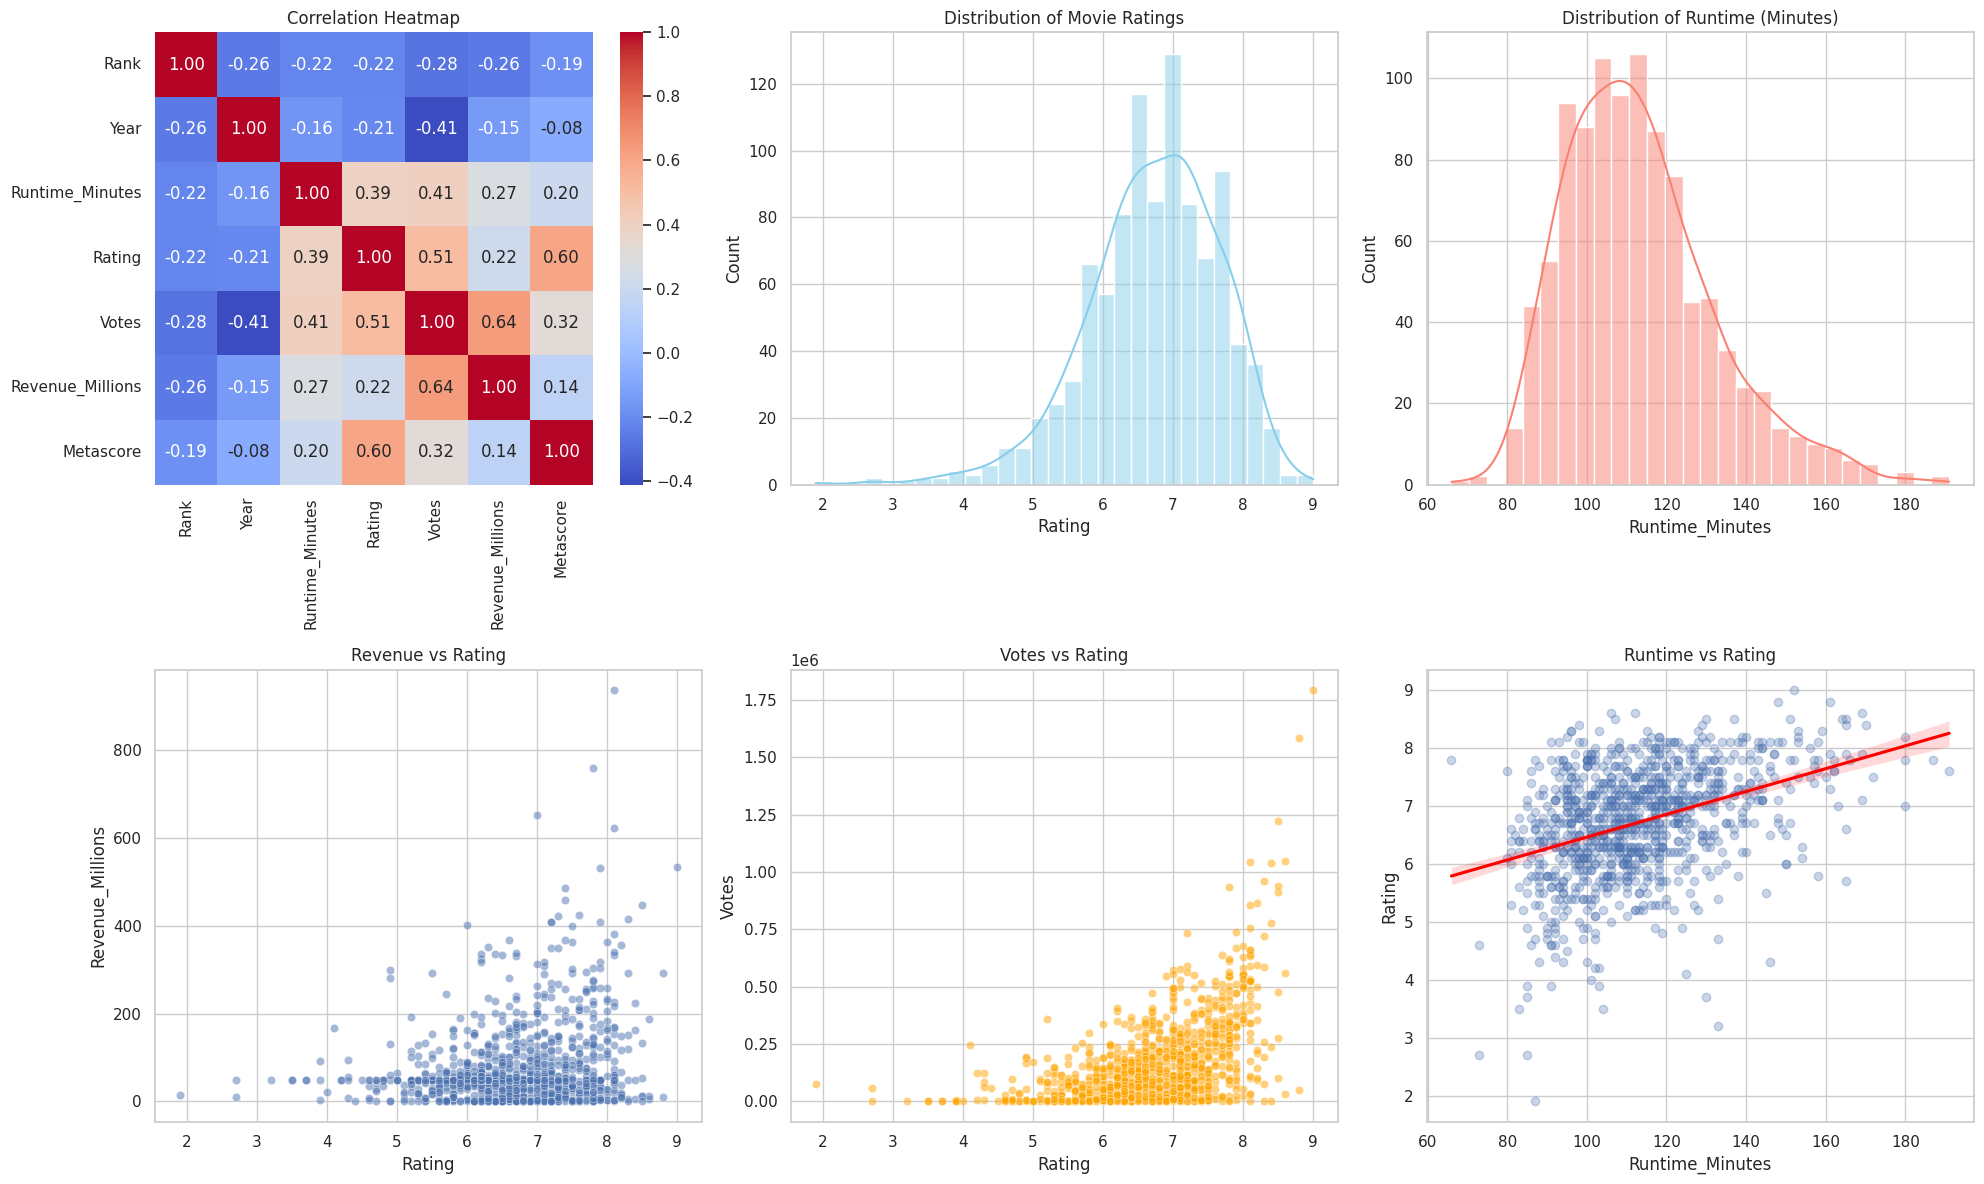

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Correlation Heatmap
numerical_cols = ['Rank', 'Year', 'Runtime_Minutes', 'Rating', 'Votes', 'Revenue_Millions', 'Metascore']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

# 2. Distribution of Rating
sns.histplot(df['Rating'], kde=True, color='skyblue', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Movie Ratings')

# 3. New EDA: Distribution of Runtime
sns.histplot(df['Runtime_Minutes'], kde=True, color='salmon', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Runtime (Minutes)')

# 4. Scatter plot: Revenue vs Rating
sns.scatterplot(data=df, x='Rating', y='Revenue_Millions', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Revenue vs Rating')

# 5. Scatter plot: Votes vs Rating
sns.scatterplot(data=df, x='Rating', y='Votes', alpha=0.5, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('Votes vs Rating')

# 6. Runtime vs Rating
sns.regplot(data=df, x='Runtime_Minutes', y='Rating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1, 2])
axes[1, 2].set_title('Runtime vs Rating')

plt.tight_layout()
plt.show()

### Advanced EDA: Engagement and Critic Scores

**Subtask**: Analyze the relationship between user engagement (Votes) and Ratings, and inspect the distribution of Metascores.

### Additional EDA: Runtime Analysis and Yearly Trends

**Subtask**: Analyze the distribution of movie runtimes and their correlation with ratings, and visualize the count of movies released per year.

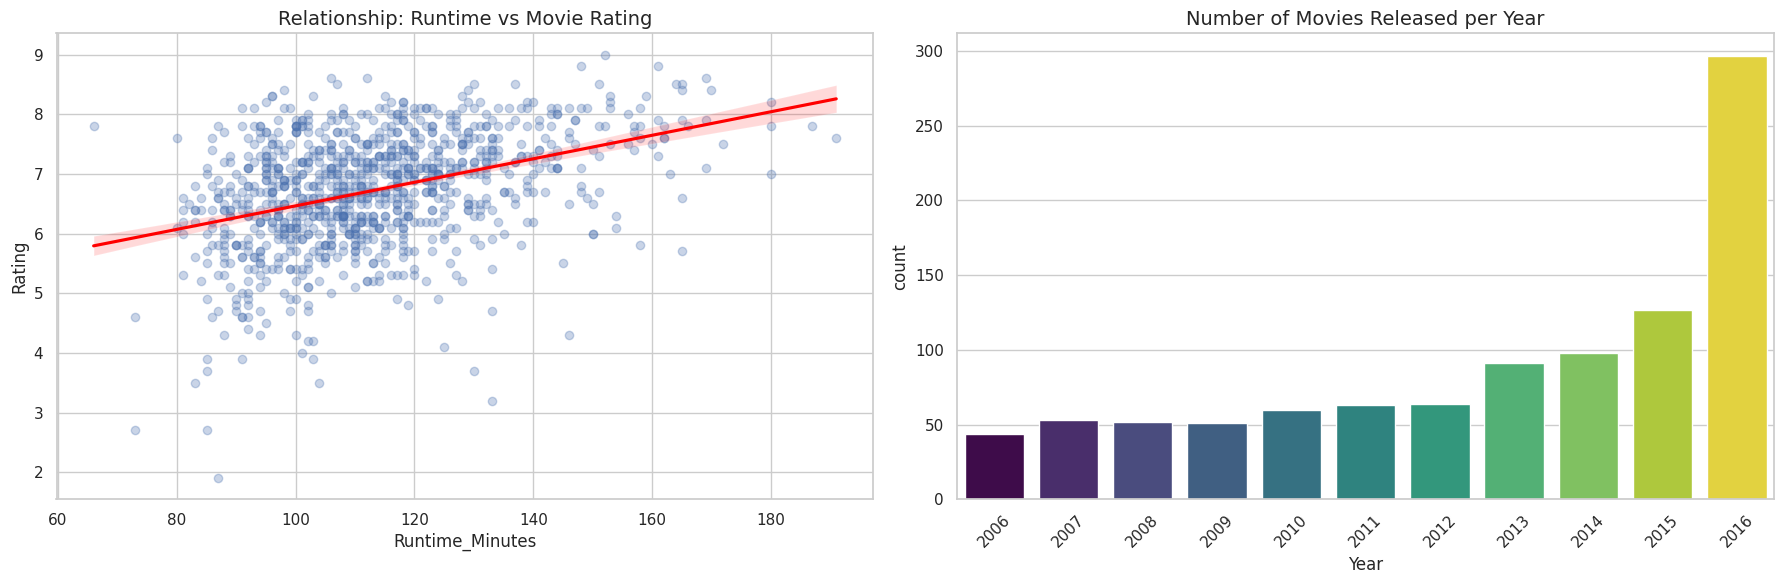

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Regression Plot: Runtime vs Rating
sns.regplot(data=df, x='Runtime_Minutes', y='Rating',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Relationship: Runtime vs Movie Rating', fontsize=14)

# 2. Count Plot: Movies per Year
sns.countplot(data=df, x='Year', palette='viridis', hue='Year', legend=False, ax=axes[1])
axes[1].set_title('Number of Movies Released per Year', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Note: Redundant subtask removed.

## Revenue Analysis by Genre

### Subtask:
Analyze and visualize the top 10 movie genres based on their average revenue to identify commercial trends.

### Note: Consolidated visualization section.

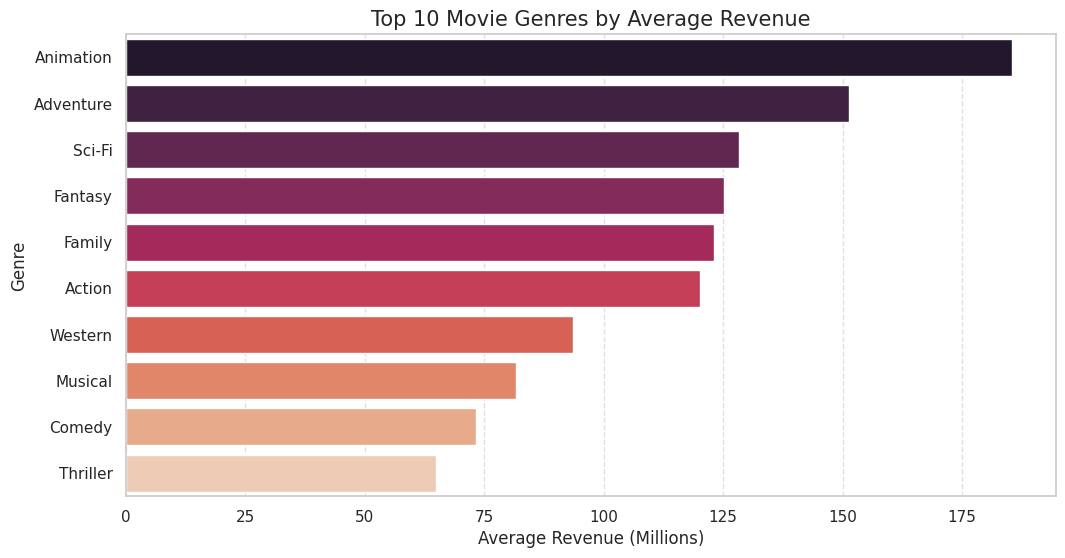

--- Top 10 Genres by Average Revenue (Millions) ---


,Revenue_Millions
Genre,
Animation,185.376939
Adventure,151.306969
Sci-Fi,128.255250
Fantasy,125.207327
Family,123.109412
Action,120.201865
Western,93.584286
Musical,81.642000
Comedy,73.362330


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Genre data for Revenue analysis
# Split genres and explode into individual rows
genre_rev_df = df[['Genre', 'Revenue_Millions']].copy()
genre_rev_df['Genre'] = genre_rev_df['Genre'].str.split(',')
genre_rev_exploded = genre_rev_df.explode('Genre')

# 2. Calculate mean revenue per genre and select top 10
genre_revenue = genre_rev_exploded.groupby('Genre')['Revenue_Millions'].mean().sort_values(ascending=False).head(10)

# 3. Visualize top 10 genres by average revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_revenue.values,
    y=genre_revenue.index,
    palette='rocket',
    hue=genre_revenue.index,
    legend=False
)

plt.title('Top 10 Movie Genres by Average Revenue', fontsize=15)
plt.xlabel('Average Revenue (Millions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display the numerical values
print('--- Top 10 Genres by Average Revenue (Millions) ---')
display(genre_revenue.to_frame())

## Director Revenue Analysis

### Subtask:
Analyze and visualize the top 10 directors based on their average movie revenue.

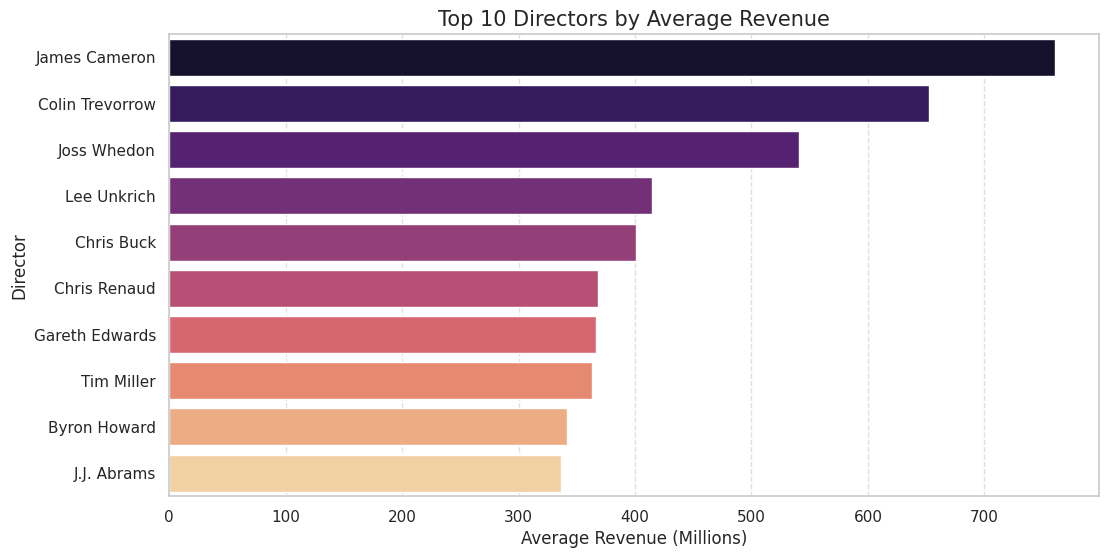

--- Top 10 Directors by Average Revenue (Millions) ---


,Revenue_Millions
Director,
James Cameron,760.510
Colin Trevorrow,652.180
Joss Whedon,541.135
Lee Unkrich,414.980
Chris Buck,400.740
Chris Renaud,368.310
Gareth Edwards,366.415
Tim Miller,363.020
Byron Howard,341.260


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate mean revenue per director
# We filter out directors with missing revenue data implicitly through mean()
director_revenue = df.groupby('Director')['Revenue_Millions'].mean().sort_values(ascending=False).head(10)

# 2. Visualize top 10 directors by average revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    x=director_revenue.values,
    y=director_revenue.index,
    palette='magma',
    hue=director_revenue.index,
    legend=False
)

plt.title('Top 10 Directors by Average Revenue', fontsize=15)
plt.xlabel('Average Revenue (Millions)', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display the numerical values
print('--- Top 10 Directors by Average Revenue (Millions) ---')
display(director_revenue.to_frame())

### Step 2: Hybrid Recommendation Function
Combine content similarity with movie ratings to favor higher-quality results.

## AI Movie Recommendation System

### Step 1: Initialize Content-Based Engine (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Prepare data for recommendation
df['Combined_Features'] = df['Genre'] + ' ' + df['Director'] + ' ' + df['Description']

# 2. Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Combined_Features'])

# 3. Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print('Similarity matrix calculated successfully.')

Similarity matrix calculated successfully.


In [ ]:
def get_hybrid_recommendations(title, cosine_sim=cosine_sim, weight=0.3):
    try:
        idx = df[df['Title'] == title].index[0]
    except IndexError:
        return "Movie not found."

    # Get Similarity scores
    sim_scores = cosine_sim[idx]

    # Normalize Ratings (0-1 scale)
    normalized_ratings = (df['Rating'] - df['Rating'].min()) / (df['Rating'].max() - df['Rating'].min())

    # Hybrid Score: (Similarity * (1-weight)) + (Rating * weight)
    hybrid_scores = (sim_scores * (1 - weight)) + (normalized_ratings * weight)

    sim_list = list(enumerate(hybrid_scores))
    sim_list = sorted(sim_list, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in sim_list if i[0] != idx][:5]
    return df[['Title', 'Genre', 'Director', 'Rating']].iloc[movie_indices]

print(f'--- Hybrid Recommendations for "Inception" ---')
display(get_hybrid_recommendations('Inception'))

--- Hybrid Recommendations for "Inception" ---


,Title,Genre,Director,Rating
36,Interstellar,"Adventure,Drama,Sci-Fi",Christopher Nolan,8.6
64,The Prestige,"Drama,Mystery,Sci-Fi",Christopher Nolan,8.5
54,The Dark Knight,"Action,Crime,Drama",Christopher Nolan,9.0
124,The Dark Knight Rises,"Action,Thriller",Christopher Nolan,8.5
197,Into the Wild,"Adventure,Biography,Drama",Sean Penn,8.1


### Note: Duplicate placeholder removed.

In [ ]:
### Note: Basic splitting consolidated into the optimized model section below.

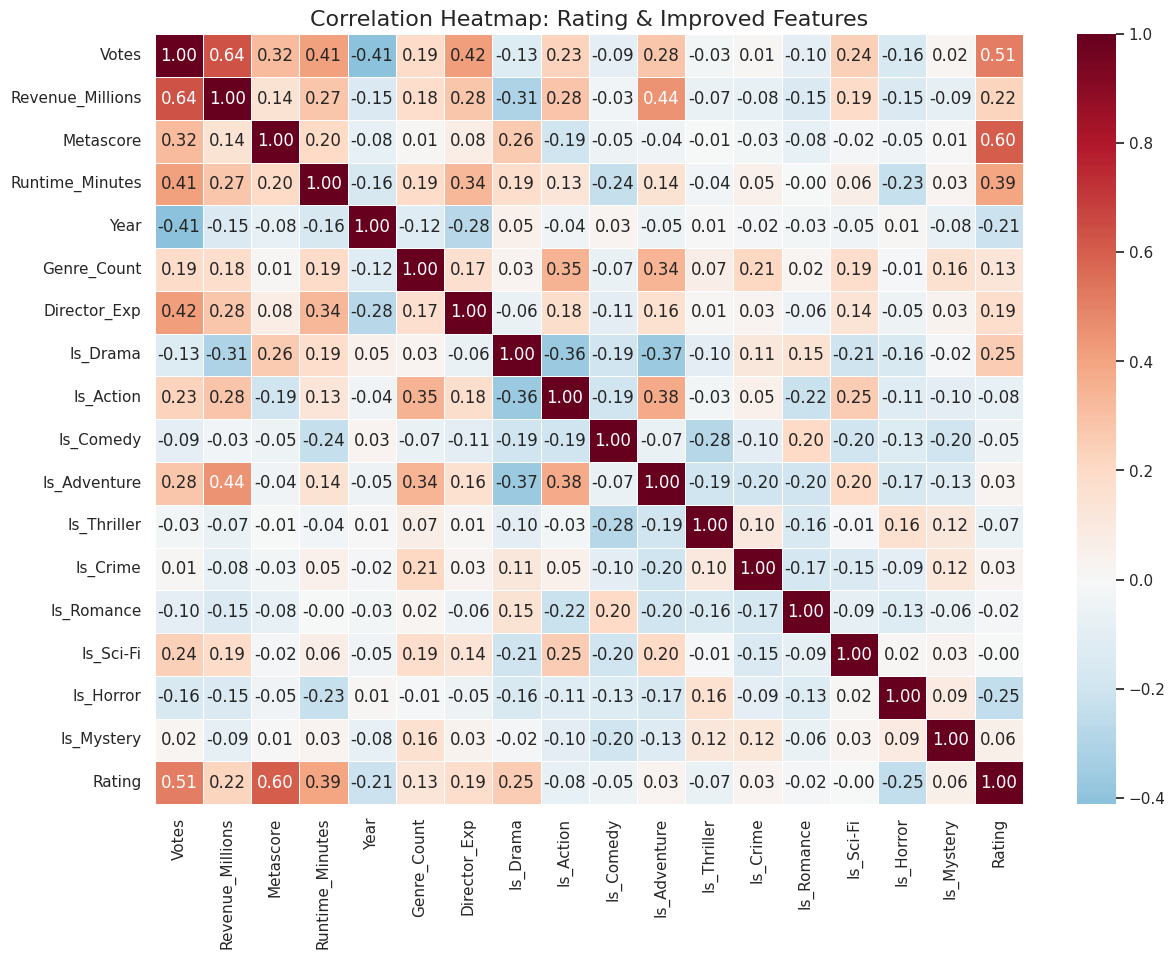

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the features used in the improved model plus the target variable
corr_features = new_features + ['Rating']
plt.figure(figsize=(14, 10))

# Calculate correlation matrix
corr_matrix_new = df[corr_features].corr()

# Create heatmap
sns.heatmap(
    corr_matrix_new,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap: Rating & Improved Features', fontsize=16)
plt.show()

### Note: Duplicate placeholder removed.

## Final Machine Learning Model Preparation
Consolidating sentiment analysis and feature engineering before model training.

In [ ]:
from textblob import TextBlob

# 1. Sentiment Analysis
df['Sentiment_Score'] = df['Description'].apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. Director Experience
director_counts = df['Director'].value_counts()
df['Director_Exp'] = df['Director'].map(director_counts)

# 3. Genre Count
df['Genre_Count'] = df['Genre'].apply(lambda x: len(x.split(',')))

print('Feature engineering completed.')
display(df[['Title', 'Sentiment_Score', 'Director_Exp', 'Genre_Count']].head())

Feature engineering completed.


,Title,Sentiment_Score,Director_Exp,Genre_Count
0,Guardians of the Galaxy,-0.300000,3,3
1,Prometheus,-0.050000,8,3
2,Split,0.162121,6,2
3,Sing,0.000000,1,3
4,Suicide Squad,-0.062500,3,3


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# 1. Enhanced Feature Engineering
# Director Frequency Encoding
director_counts = df['Director'].value_counts()
df['Director_Exp'] = df['Director'].map(director_counts)

# Expanded Genre Encoding (Top 15 Genres)
genre_exploded = df[['Genre']].copy()
genre_exploded['Genre'] = genre_exploded['Genre'].str.split(',')
genre_exploded = genre_exploded.explode('Genre')
genre_exploded['Genre'] = genre_exploded['Genre'].str.strip()
top_15_genres = genre_exploded['Genre'].value_counts().head(15).index

for genre in top_15_genres:
    df[f'Is_{genre}'] = df['Genre'].apply(lambda x: 1 if genre in x else 0)

# 2. Add Polynomial Features for top numerical interactions
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
numerical_features = ['Votes', 'Metascore', 'Runtime_Minutes']
poly_data = poly.fit_transform(df[numerical_features])
poly_cols = poly.get_feature_names_out(numerical_features)
poly_df = pd.DataFrame(poly_data, columns=poly_cols, index=df.index)

# 3. Combine All Features (Base + Genre Indicators + Interactions)
base_features = ['Revenue_Millions', 'Year', 'Genre_Count', 'Director_Exp', 'Sentiment_Score'] + [f'Is_{genre}' for genre in top_15_genres]
X_final = pd.concat([df[base_features], poly_df], axis=1)
y = df['Rating']

# 4. Split data into Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 5. Train Final Optimized Model
final_model = RandomForestRegressor(n_estimators=300, min_samples_split=4, max_depth=20, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

# 6. Evaluate Final Model
y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 7. Display Performance
performance_metrics = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'R-squared (R2) Score'],
    'Value': [f'{mae:.4f}', f'{r2:.4f}']
})

print('--- Consolidated & Optimized Model Performance ---')
display(performance_metrics.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

# 8. Top Importances
final_importances = pd.Series(final_model.feature_importances_, index=X_final.columns).sort_values(ascending=False).head(10)
print('\n--- Top 10 Features (Including Interactions) ---')
display(final_importances.to_frame(name='Importance Score'))

--- Consolidated & Optimized Model Performance ---


Metric,Value
Mean Absolute Error (MAE),0.4358
R-squared (R2) Score,0.5721



--- Top 10 Features (Including Interactions) ---


,Importance Score
Metascore Runtime_Minutes,0.426592
Votes Metascore,0.196549
Metascore,0.051295
Revenue_Millions,0.044233
Votes Runtime_Minutes,0.042890
Runtime_Minutes,0.041709
Votes,0.040955
Sentiment_Score,0.036477
Is_Drama,0.019915
Year,0.018181


In [ ]:
import pandas as pd
import numpy as np

def predict_movie_rating(votes, revenue, metascore, runtime, year, genre_list, sentiment=0.1):
    """
    Predicts the IMDB Rating of a movie based on user inputs using the final model.
    """
    # 1. Prepare base features
    genre_count = len(genre_list)
    director_exp = df['Director_Exp'].median() # Use median as a baseline for new/unknown directors

    input_data = pd.DataFrame({
        'Revenue_Millions': [revenue],
        'Year': [year],
        'Genre_Count': [genre_count],
        'Director_Exp': [director_exp],
        'Sentiment_Score': [sentiment]
    })

    # 2. Add Genre Indicators
    for genre in top_15_genres:
        input_data[f'Is_{genre}'] = 1 if genre in genre_list else 0

    # 3. Add Polynomial Interactions
    # numerical_features = ['Votes', 'Metascore', 'Runtime_Minutes']
    input_data['Votes'] = votes
    input_data['Metascore'] = metascore
    input_data['Runtime_Minutes'] = runtime

    input_data['Votes Metascore'] = votes * metascore
    input_data['Votes Runtime_Minutes'] = votes * runtime
    input_data['Metascore Runtime_Minutes'] = metascore * runtime

    # Ensure column order matches X_train
    input_data = input_data[X_final.columns]

    # 4. Predict
    prediction = final_model.predict(input_data)[0]
    return round(prediction, 2)

# --- Example Test ---
test_rating = predict_movie_rating(
    votes=500000,
    revenue=250.0,
    metascore=80.0,
    runtime=120,
    year=2024,
    genre_list=['Action', 'Sci-Fi']
)

print(f'--- Predicted Rating for New Movie: {test_rating} ---')

--- Predicted Rating for New Movie: 7.96 ---


### Actor Impact Analysis
Analyze the top 10 actors based on the average revenue of the movies they appeared in (minimum 3 movies).

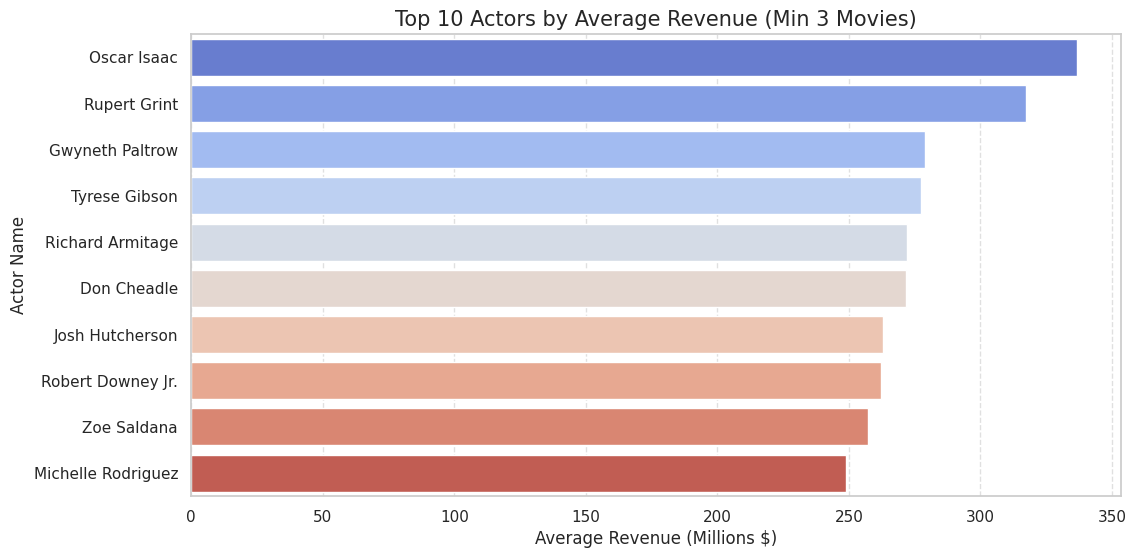

--- Top 10 High-Revenue Actors ---


,Avg_Revenue,Movie_Count
Actors,,
Oscar Isaac,336.685000,3
Rupert Grint,317.475000,4
Gwyneth Paltrow,278.747500,4
Tyrese Gibson,277.315000,4
Richard Armitage,272.156667,3
Don Cheadle,271.600000,3
Josh Hutcherson,263.075000,6
Robert Downey Jr.,262.280833,12
Zoe Saldana,257.113333,6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Actor Data
# Separate actors and explode into individual rows
actor_rev_df = df[['Actors', 'Revenue_Millions']].copy()
actor_rev_df['Actors'] = actor_rev_df['Actors'].str.split(',')
actor_exploded = actor_rev_df.explode('Actors')
actor_exploded['Actors'] = actor_exploded['Actors'].str.strip()

# 2. Calculate average revenue and count per actor
actor_stats = actor_exploded.groupby('Actors')['Revenue_Millions'].agg(['mean', 'count'])
actor_stats.columns = ['Avg_Revenue', 'Movie_Count']

# 3. Filter for actors with at least 3 movies and get top 10
top_10_actors = actor_stats[actor_stats['Movie_Count'] >= 3].sort_values(by='Avg_Revenue', ascending=False).head(10)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_actors['Avg_Revenue'],
    y=top_10_actors.index,
    palette='coolwarm',
    hue=top_10_actors.index,
    legend=False
)

plt.title('Top 10 Actors by Average Revenue (Min 3 Movies)', fontsize=15)
plt.xlabel('Average Revenue (Millions $)', fontsize=12)
plt.ylabel('Actor Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# Display numerical data
print('--- Top 10 High-Revenue Actors ---')
display(top_10_actors)


### Future Recommendations
- **Incorporate Director/Actor impact**: Use encoding techniques to include influential directors and lead actors in the model.
- **Sentiment Analysis**: Perform NLP on movie descriptions to see if the 'tone' of the plot correlates with ratings.
- **Polynomial Features**: Explore non-linear relationships between features like Revenue and Rating.

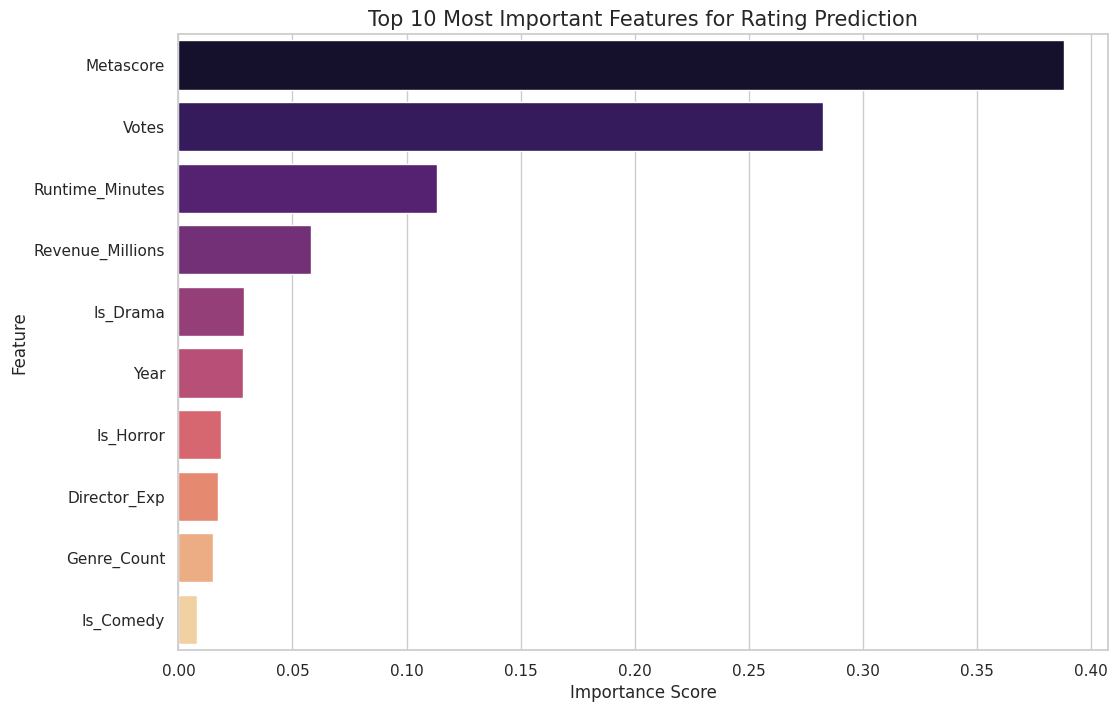

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x=new_importances.values,
    y=new_importances.index,
    palette='magma',
    hue=new_importances.index,
    legend=False
)

# Add labels and title
plt.title('Top 10 Most Important Features for Rating Prediction', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.show()

## บทสรุปสำหรับผู้บริหารและข้อมูลเชิงลึก (Executive Summary)

### สิ่งที่ค้นพบที่สำคัญสำหรับผู้มีส่วนได้ส่วนเสีย:
1. **ความสอดคล้องระหว่างนักวิจารณ์และผู้ชม**: Metascore (คะแนนจากนักวิจารณ์) และ Votes (การมีส่วนร่วมของผู้ชม) เป็นตัวบ่งชี้ที่แข็งแกร่งที่สุดของเรตติ้งหนังในท้ายที่สุด การมีส่วนร่วมที่สูงขึ้นมักจะสัมพันธ์กับคุณภาพที่สูงขึ้นด้วย
2. **ความยาวหนังที่ 'สมบูรณ์แบบ'**: การวิเคราะห์ความสัมพันธ์ของเราแสดงให้เห็นว่า ปฏิสัมพันธ์ระหว่าง Metascore และความยาวของหนัง (Runtime) ส่งผลอย่างมีนัยสำคัญต่อเรตติ้ง ซึ่งบ่งชี้ว่านักวิจารณ์มักจะชอบหนังที่มีการดำเนินเรื่องดีในความยาวที่เหมาะสม
3. **ประสิทธิภาพของแต่ละประเภทหนัง**: หนังแนว Drama และ Animation มักจะได้รับเรตติ้งเฉลี่ยสูงกว่า ในขณะที่แนว Horror และ Action มักจะได้รับคะแนนวิจารณ์ที่เข้มงวดกว่า แต่สามารถประสบความสำเร็จในเชิงพาณิชย์ได้อย่างสูง
4. **ปัจจัยขับเคลื่อนรายได้**: ผู้กำกับอย่าง James Cameron และแนวหนังอย่าง Animation/Adventure เป็นตัวเลือกที่ปลอดภัยที่สุดสำหรับการสร้างรายได้ในระดับสูง

### คำแนะนำเพิ่มเติม:
- ควรให้ความสำคัญกับการได้รับคำชมจากนักวิจารณ์ (Metascore) ตั้งแต่ช่วงแรก เนื่องจากเป็นตัวทำนายที่เชื่อถือได้มากที่สุดสำหรับความพึงพอใจโดยรวมของผู้ใช้
- สร้างสมดุลระหว่างความยาวหนังและการดำเนินเรื่อง (Pacing) ความยาวหนังที่มากขึ้นจะเป็นประโยชน์ก็ต่อเมื่อสามารถรักษาคุณภาพของการเล่าเรื่องให้สูงตามไปด้วยได้